In [1]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
# ============================================================
# DATA — Official frozen panel (May 2026)
# ============================================================
# All source data was fetched from Eurostat (gov_rrf_fa,
# nrg_inf_epcrw, nrg_inf_epc, nrg_ind_ren, nrg_ind_id,
# nama_10_pc, demo_pjan) and World Bank WGI in May 2026
# and saved to panel_step6_official.xlsx. The panel is loaded
# directly from this file to ensure reproducibility, as
# Eurostat periodically revises published figures.

panel = pd.read_excel('panel_step6_official.xlsx')

# ---- Cyprus loan patch ----
# Eurostat gov_rrf_fa removed CY LOAN F2R_F4R/NET/STK values
# for 2022-2024 after the official data pull (May 2026).
# Values sourced from rrf_raw.xlsx and confirmed against the
# saved panel. Hard-coded here for reproducibility.
cy_loan_patch = {
    2022: {'loans_main_pc_gdp': 0.09, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
    2023: {'loans_main_pc_gdp': 0.08, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
    2024: {'loans_main_pc_gdp': 0.07, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
}
for year, vals in cy_loan_patch.items():
    mask = (panel['country'] == 'CY') & (panel['year'] == year)
    for col, val in vals.items():
        panel.loc[mask, col] = val

# Recompute interaction terms after patch
panel['loans_x_baseline'] = (
    panel['loans_main_pc_gdp'] * panel['baseline_re_share']
)

# Verify
print(f"Panel loaded: {panel.shape[0]} rows, {panel['country'].nunique()} countries")
print(f"Years: {sorted(panel['year'].unique())}")
print(f"\nCyprus loan patch — verify:")
cy_check = panel[
    (panel['country'] == 'CY') &
    (panel['year'].isin([2021, 2022, 2023, 2024]))
][['country', 'year', 'loans_main_pc_gdp', 'loans_main_mio_eur']]
print(cy_check.to_string(index=False))

Panel loaded: 189 rows, 27 countries
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Cyprus loan patch — verify:
country  year  loans_main_pc_gdp  loans_main_mio_eur
     CY  2021               0.10                26.0
     CY  2022               0.09                26.0
     CY  2023               0.08                26.0
     CY  2024               0.07                26.0


In [3]:
# ============================================================
# STEP 7 — DESCRIPTIVE STATISTICS
# ============================================================


# ---- Define regression variables for summary table ----
reg_vars = {
    'delta_mw':              'ΔMW (primary DV)',
    'grants_main_pc_gdp':    'Grants (% GDP)',
    'grants_main_mio_eur':   'Grants (MIO EUR)',
    'loans_main_pc_gdp':     'Loans (% GDP)',
    'loans_main_mio_eur':    'Loans (MIO EUR)',
    'grants_x_baseline':     'Grants × Baseline RE',
    'loans_x_baseline':      'Loans × Baseline RE',
    'baseline_re_share':     'Baseline RE share (%)',
    'log_gdp_eur':           'Log GDP per capita',
    'population':            'Population',
    'energy_import_dep_pct': 'Energy import dependency (%)',
    'gov_eff':               'Government effectiveness',
    'gov_ideology':          'Government ideology (0-10)',
    'fossil_share':          'Fossil share (%)',
}

# ============================================================
# 7.1 — SUMMARY STATISTICS
# Full panel (189 obs) except delta_mw (162 obs, 2018 excluded)
# ============================================================

rows = []
for col, label in reg_vars.items():
    s = panel[col].dropna()
    rows.append({
        'Variable': label,
        'N':        int(s.count()),
        'Mean':     round(s.mean(), 3),
        'SD':       round(s.std(), 3),
        'Min':      round(s.min(), 3),
        'Max':      round(s.max(), 3),
    })

df_summary = pd.DataFrame(rows)
print("=== 7.1 SUMMARY STATISTICS ===")
print(df_summary.to_string(index=False))

# ============================================================
# 7.2 — BASELINE RE SHARE BY COUNTRY
# ============================================================

df_baseline_ranked = (
    panel[['country', 'baseline_re_share']]
    .drop_duplicates()
    .sort_values('baseline_re_share', ascending=False)
    .reset_index(drop=True)
)
df_baseline_ranked.index += 1

print("\n=== 7.2 BASELINE RE SHARE BY COUNTRY (2019-2020 avg) ===")
print(df_baseline_ranked.to_string())

# ============================================================
# 7.3 — RRF DISBURSEMENT BY COUNTRY (2021-2024 totals)
# ============================================================

df_rrf_country = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('country')[['grants_main_mio_eur', 'loans_main_mio_eur']]
    .sum()
    .rename(columns={
        'grants_main_mio_eur': 'Total Grants (MIO EUR)',
        'loans_main_mio_eur':  'Total Loans (MIO EUR)'
    })
    .sort_values('Total Grants (MIO EUR)', ascending=False)
    .reset_index()
)

df_rrf_country_pct = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('country')['grants_main_pc_gdp']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'grants_main_pc_gdp': 'Avg Grants (% GDP)'})
)

df_rrf_country = df_rrf_country.merge(df_rrf_country_pct, on='country')

print("\n=== 7.3 RRF DISBURSEMENT BY COUNTRY (2021-2024 totals) ===")
print(df_rrf_country.to_string(index=False))

# ============================================================
# 7.4 — RRF DISBURSEMENT BY YEAR (EU27 totals)
# ============================================================

df_rrf_year = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('year')[['grants_main_mio_eur', 'loans_main_mio_eur']]
    .sum()
    .rename(columns={
        'grants_main_mio_eur': 'Total Grants (MIO EUR)',
        'loans_main_mio_eur':  'Total Loans (MIO EUR)'
    })
    .reset_index()
)

print("\n=== 7.4 RRF DISBURSEMENT BY YEAR (EU27 totals) ===")
print(df_rrf_year.to_string(index=False))

# ============================================================
# 7.5 — CAPACITY ADDITION TRENDS (mean ΔMW per year)
# ============================================================

df_deltamw_year = (
    panel[panel['year'] != 2018]
    .groupby('year')['delta_mw']
    .agg(
        Mean_delta_mw=lambda x: round(x.mean(), 1),
        SD_delta_mw=  lambda x: round(x.std(), 1),
        Min_delta_mw= lambda x: round(x.min(), 1),
        Max_delta_mw= lambda x: round(x.max(), 1),
        N=            lambda x: x.count()
    )
    .reset_index()
)

print("\n=== 7.5 CAPACITY ADDITION TRENDS (mean ΔMW per year, EU27) ===")
print(df_deltamw_year.to_string(index=False))

# ============================================================
# 7.6 — CORRELATION MATRIX (regression variables only)
# ============================================================

corr_cols = [
    'delta_mw', 'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline', 'loans_x_baseline', 'baseline_re_share',
    'log_gdp_eur', 'population', 'energy_import_dep_pct',
    'gov_eff', 'gov_ideology', 'fossil_share'
]

corr_labels = {
    'delta_mw':              'ΔMW',
    'grants_main_pc_gdp':    'Grants%GDP',
    'loans_main_pc_gdp':     'Loans%GDP',
    'grants_x_baseline':     'Grants×Base',
    'loans_x_baseline':      'Loans×Base',
    'baseline_re_share':     'Baseline RE',
    'log_gdp_eur':           'LogGDP',
    'population':            'Population',
    'energy_import_dep_pct': 'EnergyImp',
    'gov_eff':               'GovEff',
    'gov_ideology':          'GovIdeology',
    'fossil_share':          'FossilSh',
}

df_corr = (
    panel[corr_cols]
    .rename(columns=corr_labels)
    .corr()
    .round(2)
)

print("\n=== 7.6 CORRELATION MATRIX ===")
print(df_corr.to_string())

# ============================================================
# 7.7 — EXPORT TO EXCEL
# ============================================================

'''with pd.ExcelWriter('step7_descriptives_official.xlsx') as writer:
    df_summary.to_excel(
        writer, sheet_name='7.1_Summary_Stats', index=False)
    df_baseline_ranked.to_excel(
        writer, sheet_name='7.2_Baseline_RE', index=True)
    df_rrf_country.to_excel(
        writer, sheet_name='7.3_RRF_by_Country', index=False)
    df_rrf_year.to_excel(
        writer, sheet_name='7.4_RRF_by_Year', index=False)
    df_deltamw_year.to_excel(
        writer, sheet_name='7.5_DeltaMW_Trends', index=False)
    df_corr.to_excel(
        writer, sheet_name='7.6_Correlation_Matrix', index=True)

print("\nExported: step7_descriptives_official.xlsx")'''

=== 7.1 SUMMARY STATISTICS ===
                    Variable   N         Mean           SD        Min          Max
            ΔMW (primary DV) 162     1776.754     2815.889   -800.512    18919.000
              Grants (% GDP) 189        0.423        0.821      0.000        4.300
            Grants (MIO EUR) 189     2534.527     7704.192      0.000    47963.000
               Loans (% GDP) 133        0.194        0.641      0.000        4.060
             Loans (MIO EUR) 133     1887.610     9158.145      0.000    75675.230
        Grants × Baseline RE 189       10.269       21.439      0.000      127.901
         Loans × Baseline RE 133        4.217       13.284      0.000       84.005
       Baseline RE share (%) 189       23.391       11.469      9.372       57.954
          Log GDP per capita 189       10.301        0.573      9.029       11.752
                  Population 189 16545848.878 21929542.165 474837.000 83456045.000
Energy import dependency (%) 189       57.843       22.1

'with pd.ExcelWriter(\'step7_descriptives_official.xlsx\') as writer:\n    df_summary.to_excel(\n        writer, sheet_name=\'7.1_Summary_Stats\', index=False)\n    df_baseline_ranked.to_excel(\n        writer, sheet_name=\'7.2_Baseline_RE\', index=True)\n    df_rrf_country.to_excel(\n        writer, sheet_name=\'7.3_RRF_by_Country\', index=False)\n    df_rrf_year.to_excel(\n        writer, sheet_name=\'7.4_RRF_by_Year\', index=False)\n    df_deltamw_year.to_excel(\n        writer, sheet_name=\'7.5_DeltaMW_Trends\', index=False)\n    df_corr.to_excel(\n        writer, sheet_name=\'7.6_Correlation_Matrix\', index=True)\n\nprint("\nExported: step7_descriptives_official.xlsx")'

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

TABLE 1 — SUMMARY STATISTICS (regression sample 2021-2024)
                 Variable   N         Mean    Std. Dev.        Min          Max
                 ΔMW (MW) 108     2138.991     3175.440    -14.000    18919.000
           Grants (% GDP) 108        0.740        0.973      0.000        4.300
            Loans (% GDP)  52        0.496        0.955      0.000        4.060
     Grants × Baseline RE 108       17.971       25.843      0.000      127.901
      Loans × Baseline RE  52       10.787       19.608      0.000       84.005
    Baseline RE share (%) 108       23.391       11.492      9.372       57.954
       Log GDP per capita 108       10.397        0.546      9.302       11.752
               Population 108 16564382.435 21995137.505 516125.000 83456045.000
   Energy import dep. (%) 108       57.392       22.311      1.412       98.965
 Government effectiveness 108        1.130        0.563     -0.078        2.191
      Government ideology 108        5.794        1.516      

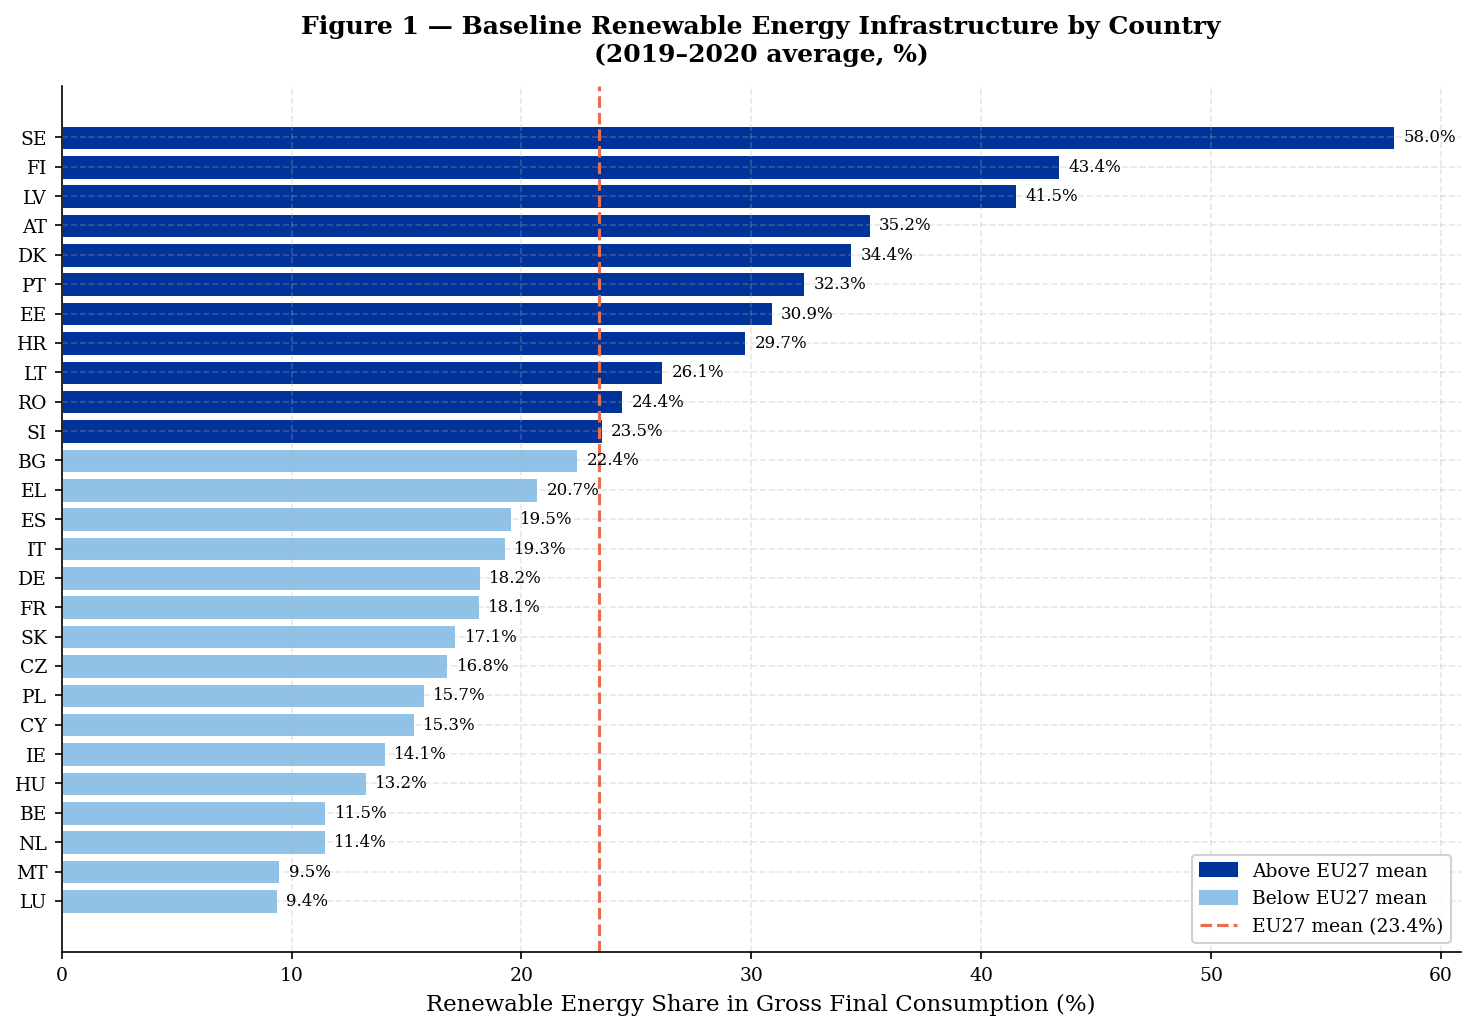

Saved: figure1_baseline_re.png


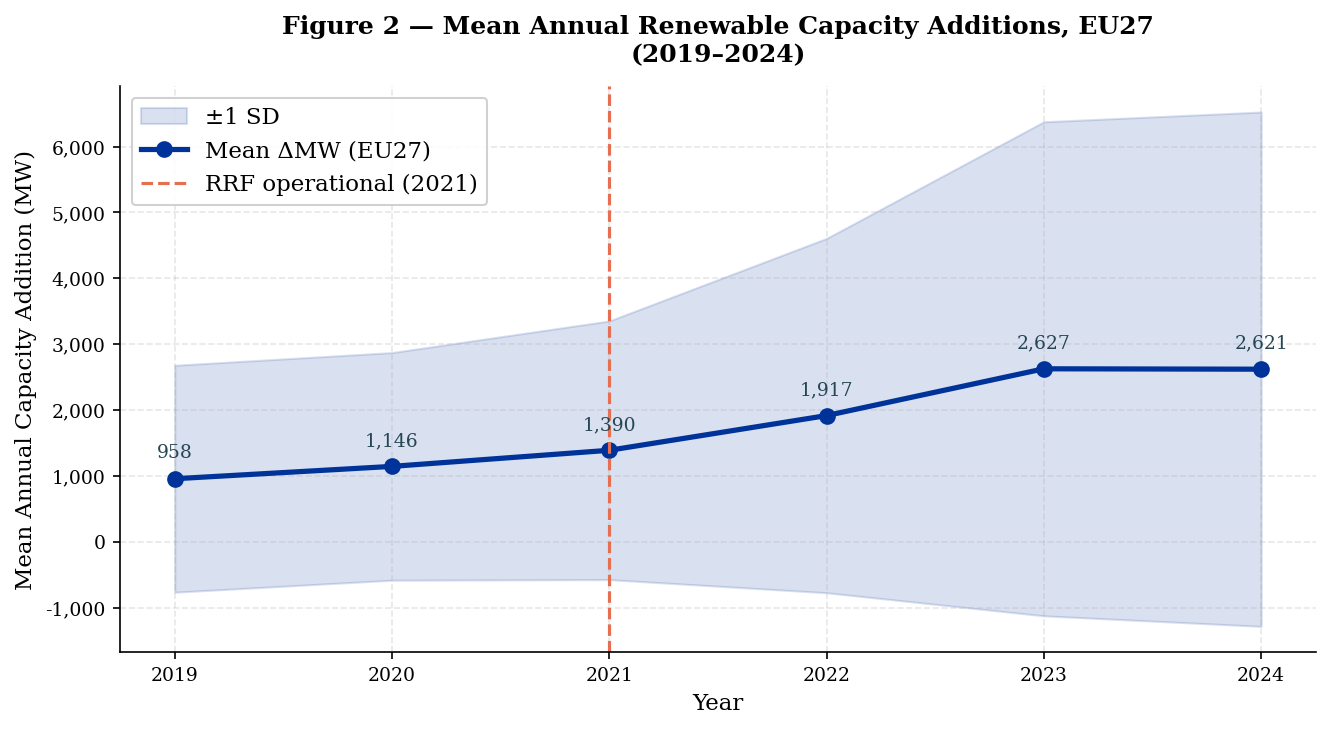

Saved: figure2_deltamw_trend.png


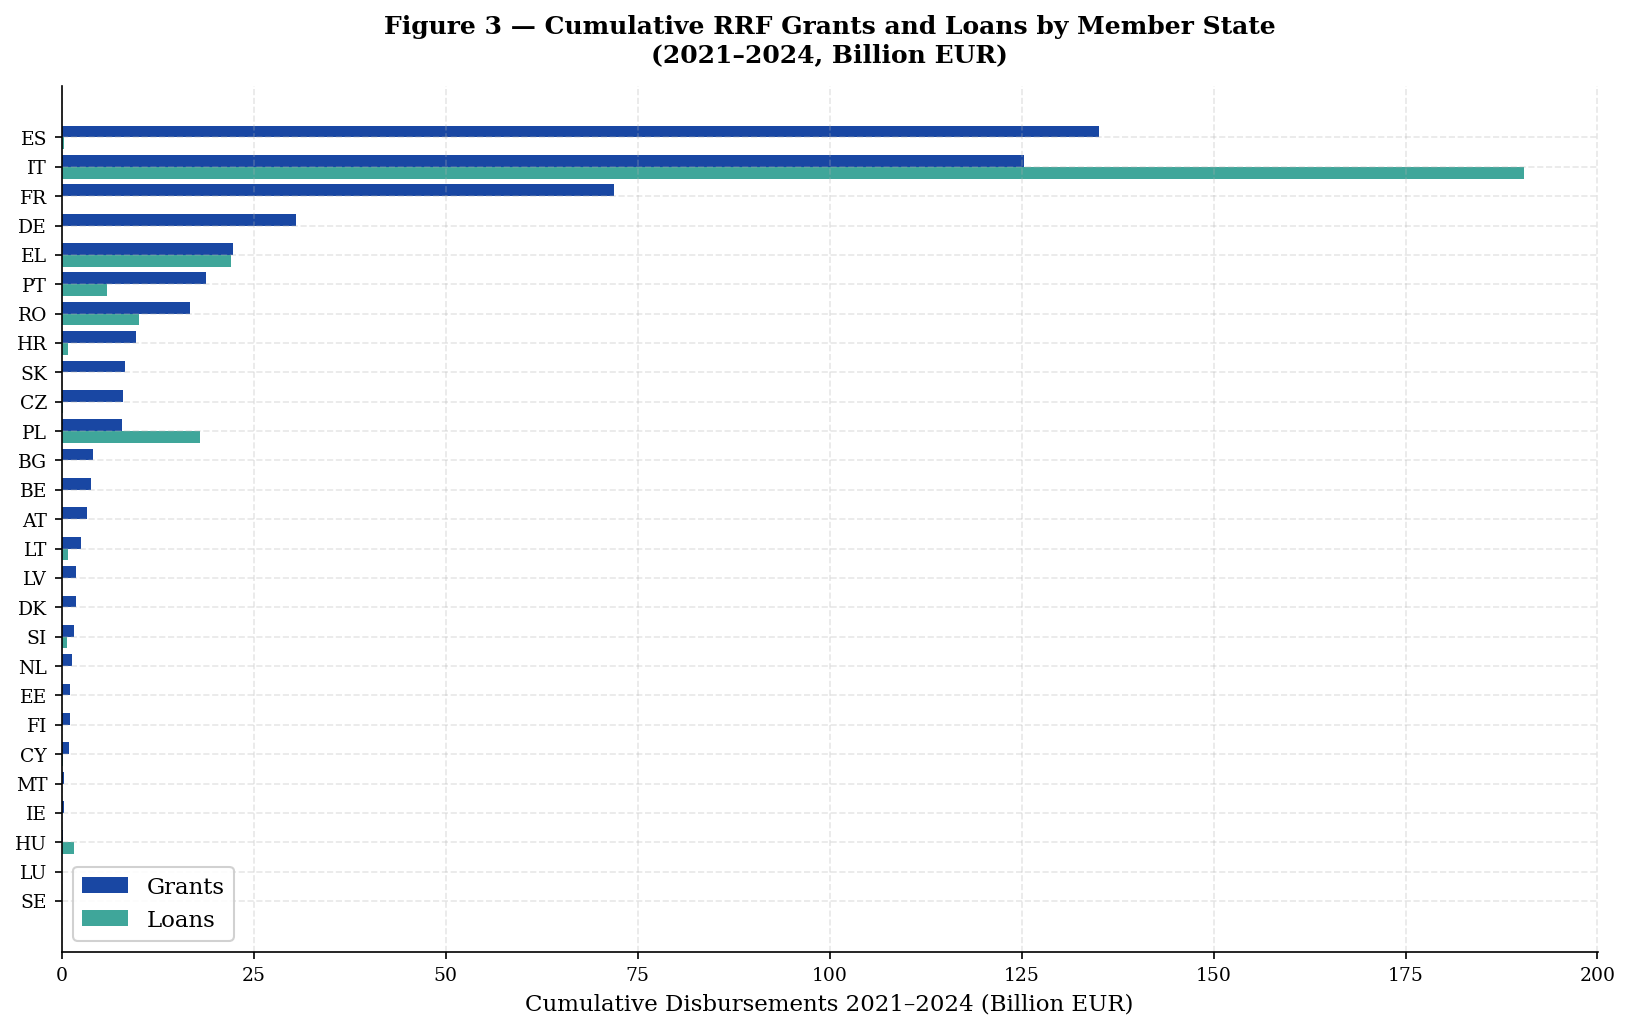

Saved: figure3_rrf_by_country.png


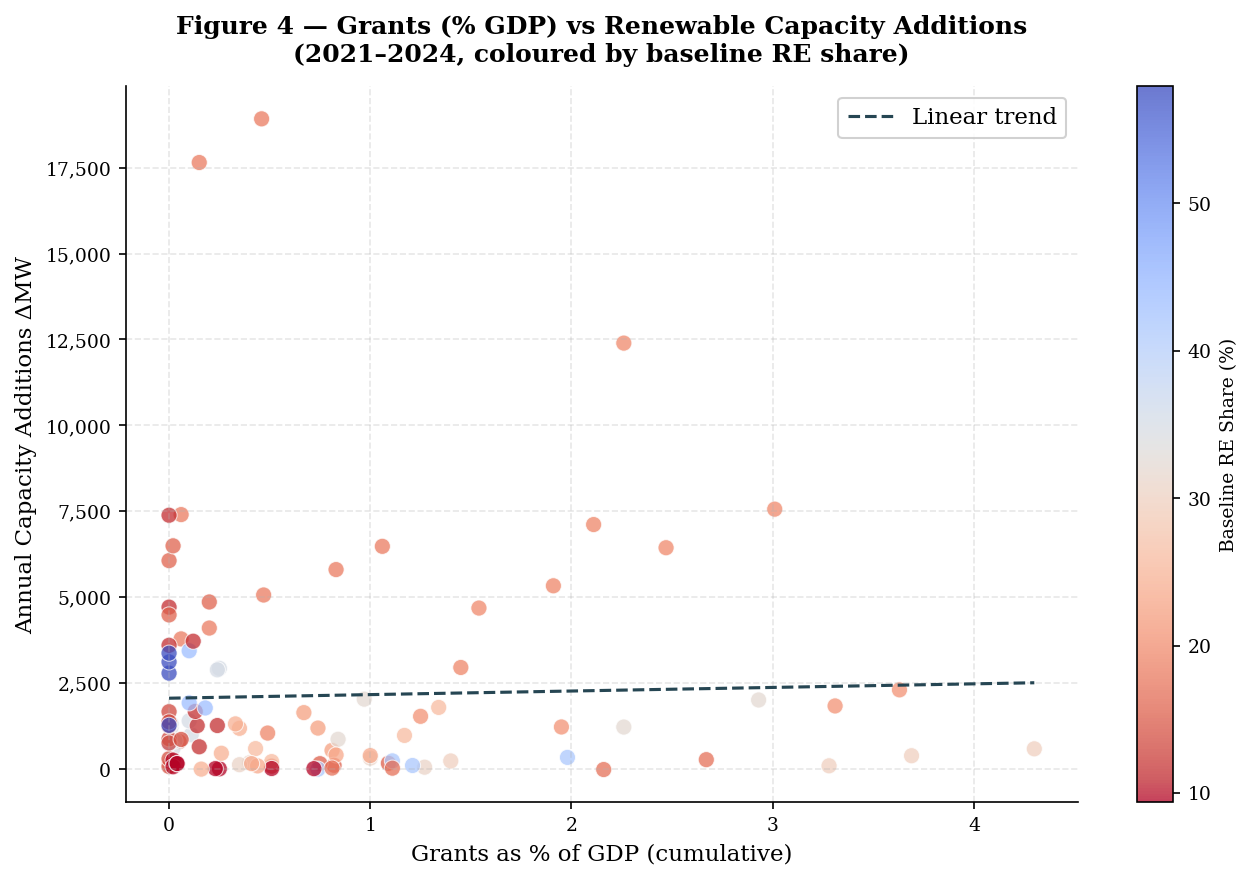

Saved: figure4_grants_vs_deltamw.png


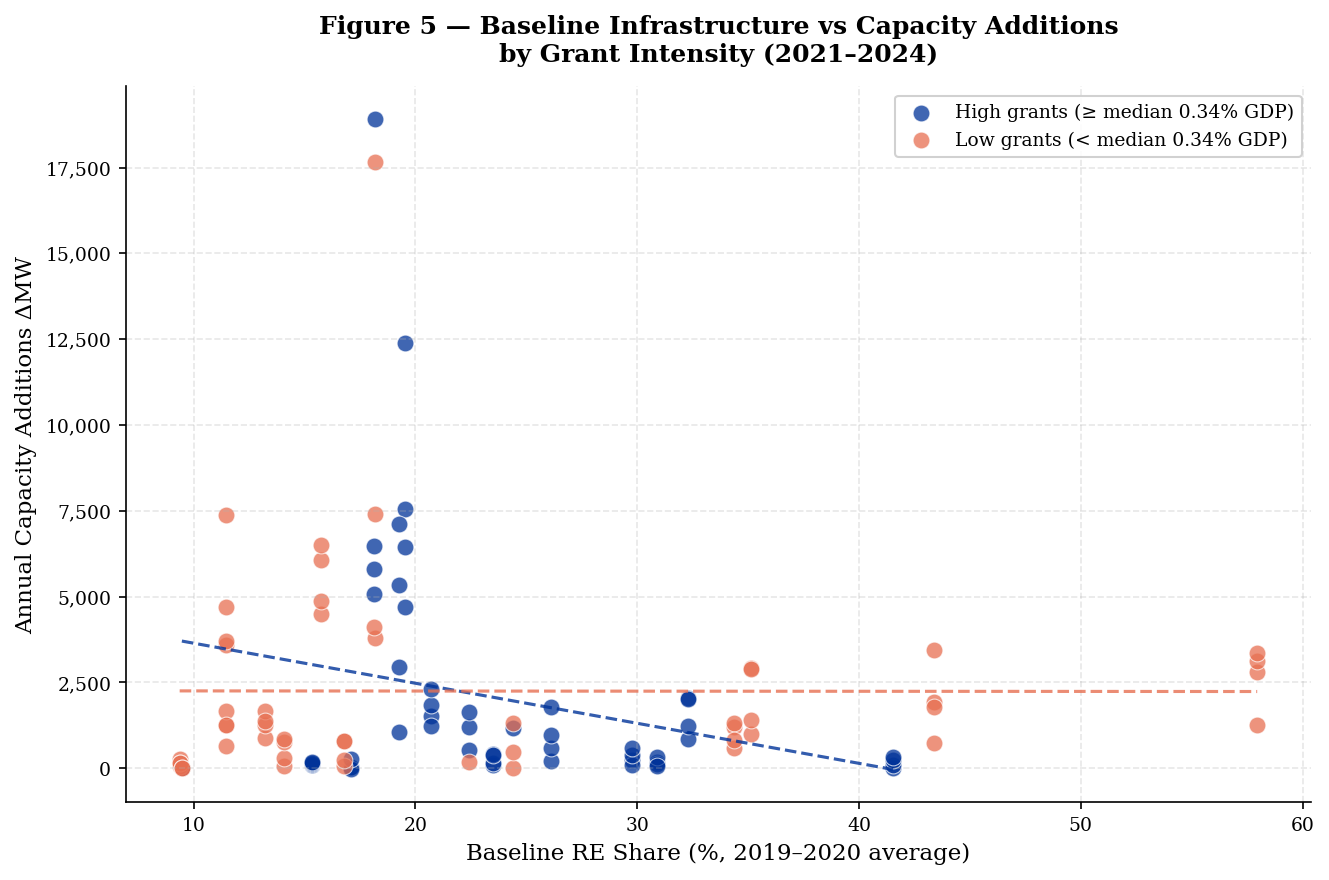

Saved: figure5_baseline_vs_deltamw.png

All figures saved. Ready for Step 8.


In [5]:
# ============================================================
# THESIS TABLES AND FIGURES
# ============================================================


# ---- Consistent style for all figures ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

EU_BLUE   = '#003399'
EU_GOLD   = '#FFCC00'
TEAL      = '#2a9d8f'
CORAL     = '#e76f51'
SLATE     = '#264653'
LIGHT_BLUE= '#90c2e7'

# ============================================================
# TABLE 1 — SUMMARY STATISTICS (thesis-formatted)
# ============================================================

reg_sample = panel[panel['year'].isin([2021, 2022, 2023, 2024])]

table1_vars = {
    'delta_mw':              'ΔMW (MW)',
    'grants_main_pc_gdp':    'Grants (% GDP)',
    'loans_main_pc_gdp':     'Loans (% GDP)',
    'grants_x_baseline':     'Grants × Baseline RE',
    'loans_x_baseline':      'Loans × Baseline RE',
    'baseline_re_share':     'Baseline RE share (%)',
    'log_gdp_eur':           'Log GDP per capita',
    'population':            'Population',
    'energy_import_dep_pct': 'Energy import dep. (%)',
    'gov_eff':               'Government effectiveness',
    'gov_ideology':          'Government ideology',
    'fossil_share':          'Fossil capacity share (%)',
}

rows = []
for col, label in table1_vars.items():
    s = reg_sample[col].dropna()
    rows.append({
        'Variable':  label,
        'N':         int(s.count()),
        'Mean':      round(s.mean(), 3),
        'Std. Dev.': round(s.std(), 3),
        'Min':       round(s.min(), 3),
        'Max':       round(s.max(), 3),
    })

df_table1 = pd.DataFrame(rows)
print("TABLE 1 — SUMMARY STATISTICS (regression sample 2021-2024)")
print(df_table1.to_string(index=False))

# ============================================================
# TABLE 2 — VARIABLE DEFINITIONS
# ============================================================

table2_data = {
    'Variable':    [
        'ΔMW',
        'Grants (% GDP)',
        'Loans (% GDP)',
        'Baseline RE share',
        'Grants × Baseline',
        'Loans × Baseline',
        'Log GDP p.c.',
        'Population',
        'Energy import dep.',
        'Gov. effectiveness',
        'Gov. ideology',
        'Fossil share',
    ],
    'Description': [
        'Year-on-year change in total installed renewable electricity capacity (hydro, geothermal, wind, solar, solid biofuels, biogases)',
        'Cumulative RRF grant receivables as % of GDP (F2R_F4R, NET, STK)',
        'Cumulative RRF loan receivables as % of GDP (F2R_F4R, NET, STK)',
        'Average RE share in gross final energy consumption, 2019–2020',
        'Grants (% GDP) × Baseline RE share',
        'Loans (% GDP) × Baseline RE share',
        'Log of GDP per capita at current prices in euros',
        'Total population (number of persons)',
        'Share of total energy needs met by imports (%)',
        'WGI Government Effectiveness estimate (–2.5 to +2.5)',
        'Seat-weighted coalition left-right score (0=left, 10=right)',
        'Combustible fuel capacity as % of total electricity capacity',
    ],
    'Unit':        [
        'MW', '% GDP', '% GDP', '%', '—', '—',
        'Log EUR', 'Persons', '%', 'Index', '0–10 scale', '%'
    ],
    'Source':      [
        'Eurostat nrg_inf_epcrw',
        'Eurostat gov_rrf_fa',
        'Eurostat gov_rrf_fa',
        'Eurostat nrg_ind_ren',
        'Constructed', 'Constructed',
        'Eurostat nama_10_pc',
        'Eurostat demo_pjan',
        'Eurostat nrg_ind_id',
        'World Bank WGI',
        'ParlGov view_cabinet',
        'Eurostat nrg_inf_epc',
    ],
    'Expected sign': [
        'DV', '+', '+/−', 'Moderator',
        '−', '+', '+', '+', '+', '+', '−', '−'
    ]
}

df_table2 = pd.DataFrame(table2_data)
print("\nTABLE 2 — VARIABLE DEFINITIONS")
print(df_table2.to_string(index=False))

# ============================================================
# TABLE 3 — CORRELATION MATRIX
# Already computed in Step 7 — reprint with thesis labels
# ============================================================

print("\nTABLE 3 — CORRELATION MATRIX (regression sample 2021-2024)")
corr_cols = [
    'delta_mw','grants_main_pc_gdp','loans_main_pc_gdp',
    'grants_x_baseline','loans_x_baseline','baseline_re_share',
    'log_gdp_eur','population','energy_import_dep_pct',
    'gov_eff','gov_ideology','fossil_share'
]
corr_labels_short = {
    'delta_mw':              '(1) ΔMW',
    'grants_main_pc_gdp':    '(2) Grants',
    'loans_main_pc_gdp':     '(3) Loans',
    'grants_x_baseline':     '(4) Gr×Base',
    'loans_x_baseline':      '(5) Lo×Base',
    'baseline_re_share':     '(6) Baseline',
    'log_gdp_eur':           '(7) LogGDP',
    'population':            '(8) Pop',
    'energy_import_dep_pct': '(9) EnergyImp',
    'gov_eff':               '(10) GovEff',
    'gov_ideology':          '(11) Ideology',
    'fossil_share':          '(12) Fossil',
}
df_corr_reg = (
    reg_sample[corr_cols]
    .rename(columns=corr_labels_short)
    .corr()
    .round(2)
)
print(df_corr_reg.to_string())

# ============================================================
# TABLE 4 — RRF DISBURSEMENT BY COUNTRY
# Already computed in Step 7 — reprint
# ============================================================

print("\nTABLE 4 — RRF DISBURSEMENT BY COUNTRY (2021-2024 cumulative)")
print(df_rrf_country.to_string(index=False))

# ============================================================
# FIGURE 1 — BASELINE RE SHARE BY COUNTRY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

df_base = (
    panel[['country', 'baseline_re_share']]
    .drop_duplicates()
    .sort_values('baseline_re_share', ascending=True)
)

colors = [EU_BLUE if v >= 23.39 else LIGHT_BLUE
          for v in df_base['baseline_re_share']]

bars = ax.barh(df_base['country'], df_base['baseline_re_share'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(23.39, color=CORAL, linestyle='--', linewidth=1.5,
           label=f'EU27 mean (23.4%)')

ax.set_xlabel('Renewable Energy Share in Gross Final Consumption (%)')
ax.set_title('Figure 1 — Baseline Renewable Energy Infrastructure by Country\n'
             '(2019–2020 average, %)', pad=12)
ax.legend(framealpha=0.9)

for bar, val in zip(bars, df_base['baseline_re_share']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

above = mpatches.Patch(color=EU_BLUE,  label='Above EU27 mean')
below = mpatches.Patch(color=LIGHT_BLUE, label='Below EU27 mean')
ax.legend(handles=[above, below,
          plt.Line2D([0],[0], color=CORAL, linestyle='--', linewidth=1.5,
                     label='EU27 mean (23.4%)')],
          framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('figure1_baseline_re.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure1_baseline_re.png")

# ============================================================
# FIGURE 2 — MEAN ΔMW PER YEAR
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

years_plot = df_deltamw_year['year'].astype(int)
means      = df_deltamw_year['Mean_delta_mw']
sds        = df_deltamw_year['SD_delta_mw']

ax.fill_between(years_plot,
                means - sds, means + sds,
                alpha=0.15, color=EU_BLUE, label='±1 SD')
ax.plot(years_plot, means, color=EU_BLUE,
        linewidth=2.5, marker='o', markersize=7,
        label='Mean ΔMW (EU27)')

ax.axvline(2021, color=CORAL, linestyle='--',
           linewidth=1.5, label='RRF operational (2021)')

for yr, mn in zip(years_plot, means):
    ax.annotate(f'{mn:,.0f}',
                xy=(yr, mn), xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=9, color=SLATE)

ax.set_xlabel('Year')
ax.set_ylabel('Mean Annual Capacity Addition (MW)')
ax.set_title('Figure 2 — Mean Annual Renewable Capacity Additions, EU27\n'
             '(2019–2024)', pad=12)
ax.set_xticks(years_plot)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure2_deltamw_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure2_deltamw_trend.png")

# ============================================================
# FIGURE 3 — RRF GRANTS AND LOANS BY COUNTRY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

df_fig3 = df_rrf_country.sort_values(
    'Total Grants (MIO EUR)', ascending=True
).copy()
df_fig3['Total Grants (BN EUR)'] = df_fig3['Total Grants (MIO EUR)'] / 1000
df_fig3['Total Loans (BN EUR)']  = df_fig3['Total Loans (MIO EUR)']  / 1000

y     = np.arange(len(df_fig3))
width = 0.4

ax.barh(y + width/2, df_fig3['Total Grants (BN EUR)'],
        width, color=EU_BLUE,  label='Grants', alpha=0.9)
ax.barh(y - width/2, df_fig3['Total Loans (BN EUR)'],
        width, color=TEAL,     label='Loans',  alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(df_fig3['country'], fontsize=9)
ax.set_xlabel('Cumulative Disbursements 2021–2024 (Billion EUR)')
ax.set_title('Figure 3 — Cumulative RRF Grants and Loans by Member State\n'
             '(2021–2024, Billion EUR)', pad=12)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure3_rrf_by_country.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure3_rrf_by_country.png")

# ============================================================
# FIGURE 4 — GRANTS % GDP vs ΔMW (SCATTER)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

scatter_data = reg_sample[
    ['country', 'year', 'grants_main_pc_gdp', 'delta_mw',
     'baseline_re_share']
].dropna()

sc = ax.scatter(
    scatter_data['grants_main_pc_gdp'],
    scatter_data['delta_mw'],
    c=scatter_data['baseline_re_share'],
    cmap='coolwarm_r',
    alpha=0.75, s=60, edgecolors='white', linewidth=0.5
)

# Trend line
z = np.polyfit(scatter_data['grants_main_pc_gdp'],
               scatter_data['delta_mw'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data['grants_main_pc_gdp'].min(),
                     scatter_data['grants_main_pc_gdp'].max(), 100)
ax.plot(x_line, p(x_line), color=SLATE, linestyle='--',
        linewidth=1.5, label='Linear trend')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Baseline RE Share (%)', fontsize=9)

ax.set_xlabel('Grants as % of GDP (cumulative)')
ax.set_ylabel('Annual Capacity Additions ΔMW')
ax.set_title('Figure 4 — Grants (% GDP) vs Renewable Capacity Additions\n'
             '(2021–2024, coloured by baseline RE share)', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure4_grants_vs_deltamw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure4_grants_vs_deltamw.png")

# ============================================================
# FIGURE 5 — BASELINE RE SHARE vs ΔMW (MODERATION SCATTER)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# Split into high/low grants recipients (above/below median grants)
median_grants = scatter_data['grants_main_pc_gdp'].median()
high_grants   = scatter_data[
    scatter_data['grants_main_pc_gdp'] >= median_grants
]
low_grants    = scatter_data[
    scatter_data['grants_main_pc_gdp'] < median_grants
]

ax.scatter(high_grants['baseline_re_share'],
           high_grants['delta_mw'],
           color=EU_BLUE, alpha=0.75, s=65,
           edgecolors='white', linewidth=0.5,
           label=f'High grants (≥ median {median_grants:.2f}% GDP)')
ax.scatter(low_grants['baseline_re_share'],
           low_grants['delta_mw'],
           color=CORAL, alpha=0.75, s=65,
           edgecolors='white', linewidth=0.5,
           label=f'Low grants (< median {median_grants:.2f}% GDP)')

# Trend lines per group
for grp, col in [(high_grants, EU_BLUE), (low_grants, CORAL)]:
    if len(grp) > 2:
        z = np.polyfit(grp['baseline_re_share'], grp['delta_mw'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(grp['baseline_re_share'].min(),
                             grp['baseline_re_share'].max(), 100)
        ax.plot(x_line, p(x_line), color=col,
                linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Baseline RE Share (%, 2019–2020 average)')
ax.set_ylabel('Annual Capacity Additions ΔMW')
ax.set_title('Figure 5 — Baseline Infrastructure vs Capacity Additions\n'
             'by Grant Intensity (2021–2024)', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('figure5_baseline_vs_deltamw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure5_baseline_vs_deltamw.png")

print("\nAll figures saved. Ready for Step 8.")

In [6]:
# ============================================================
# STEP 8 — REGRESSION ANALYSIS
# ============================================================

from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects
import scipy.stats as stats

# ---- 8.0 Prepare regression sample ----
panel_sorted = panel.sort_values(['country', 'year'])
panel_sorted['delta_re_share'] = (
    panel_sorted.groupby('country')['re_share_total'].diff()
)

reg = panel_sorted[
    panel_sorted['year'].isin(range(2021, 2025))
].copy()
reg['year']    = reg['year'].astype(int)
reg['country'] = reg['country'].astype(str)
reg = reg.set_index(['country', 'year'])

print(f"Regression sample: {len(reg)} observations")
print(f"Countries: {reg.index.get_level_values('country').nunique()}")
print(f"Years: {sorted(reg.index.get_level_values('year').unique())}")

# ---- Formula components ----
rrf_terms = '''
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline
'''

controls_full = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''

# ============================================================
# 8.1 — MODEL 1: Pooled OLS, main variables only
# ============================================================

res_m1 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.2 — MODEL 2: Pooled OLS, full controls (main specification)
# ============================================================

res_m2 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_full}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.3 — ENTITY FE
# ============================================================

res_m3 = PanelOLS.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects',
    data=reg, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.4 — TWO-WAY FE
# ============================================================

res_m4 = PanelOLS.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects + TimeEffects',
    data=reg, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.5 — HAUSMAN TEST (Entity FE vs RE)
# ============================================================

res_re = RandomEffects.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects', data=reg
).fit(cov_type='unadjusted')

print(f"RE | N={int(res_re.nobs)} | R²={res_re.rsquared:.3f} | "
      f"F={res_re.f_statistic.stat:.3f} (p={res_re.f_statistic.pval:.4f})")

b_fe     = res_m3.params
b_re     = res_re.params
common   = b_fe.index.intersection(b_re.index)
b_diff   = (b_fe[common] - b_re[common]).values
var_diff = (
    np.diag(res_m3.cov.loc[common, common].values) -
    np.diag(res_re.cov.loc[common, common].values)
)
valid        = var_diff > 0
hausman_stat = float(b_diff[valid] @ np.diag(1/var_diff[valid]) @ b_diff[valid])
hausman_df   = int(valid.sum())
hausman_p    = 1 - stats.chi2.cdf(hausman_stat, hausman_df)

print(f"\n=== HAUSMAN TEST ===")
print(f"Chi-square: {hausman_stat:.3f} | df: {hausman_df} | p: {hausman_p:.4f}")
print("Conclusion:", "FE preferred" if hausman_p < 0.05
      else "Cannot reject RE")

# ============================================================
# 8.6 — MODEL FIT SUMMARY
# ============================================================

print("\n=== MODEL FIT SUMMARY ===")
for label, res in [
    ('M1', res_m1), ('M2', res_m2),
    ('Entity FE', res_m3), ('Two-way FE', res_m4)
]:
    print(f"{label:12s} | N={int(res.nobs):3d} | R²={res.rsquared:.4f} "
          f"| R²(between)={res.rsquared_between:.4f} "
          f"| F={res.f_statistic.stat:.3f} (p={res.f_statistic.pval:.4f})")

# ============================================================
# 8.7 — ROBUSTNESS CHECKS
# ============================================================

# ---- Rob1: Alternative DV — Δ RE share (Pooled OLS) ----
res_rob1 = PooledOLS.from_formula(
    f'delta_re_share ~ 1 + {rrf_terms} + {controls_full}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Rob2: PPS-adjusted GDP (Pooled OLS) ----
controls_pps = '''
    log_gdp_pps + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''
res_rob2 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_pps}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Rob3: Gov effectiveness interaction (Pooled OLS) ----
reg['grants_x_goveff'] = (
    reg['grants_main_pc_gdp'] * reg['gov_eff']
)
controls_rob3 = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share
'''
res_rob3 = PooledOLS.from_formula(
    f'''delta_mw ~ 1 + {rrf_terms} + grants_x_goveff +
        {controls_rob3}''', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Robustness fit summary ----
print("\n=== ROBUSTNESS FIT SUMMARY ===")
for label, res in [
    ('Rob1: Δ RE share', res_rob1),
    ('Rob2: PPS GDP',    res_rob2),
    ('Rob3: GovEff×',   res_rob3),
]:
    print(f"{label:20s} | N={int(res.nobs):3d} | R²={res.rsquared:.4f} "
          f"| F={res.f_statistic.stat:.3f} (p={res.f_statistic.pval:.4f})")

# ---- Sign consistency ----
print("\n=== SIGN CONSISTENCY CHECK ===")
expected = {
    'grants_main_pc_gdp': '+',
    'loans_main_pc_gdp':  '-',
    'grants_x_baseline':  '-',
    'loans_x_baseline':   '+'
}
for var, exp_sign in expected.items():
    row = f"{var:<28} (expected {exp_sign})"
    for label, res in [
        ('Rob1', res_rob1), ('Rob2', res_rob2), ('Rob3', res_rob3)
    ]:
        actual = '+' if res.params[var] > 0 else '-'
        match  = '✓' if actual == exp_sign else '✗'
        row += f"  {label}: {actual}{match}"
    print(row)

# ============================================================
# 8.8 — FULL SUMMARIES
# ============================================================

for label, res in [
    ('M1: POOLED OLS, MAIN VARIABLES ONLY',      res_m1),
    ('M2: POOLED OLS, FULL CONTROLS',             res_m2),
    ('M3: ENTITY FE',                             res_m3),
    ('M4: TWO-WAY FE',                            res_m4),
    ('ROB1: Δ RE SHARE (Pooled OLS)',             res_rob1),
    ('ROB2: PPS GDP (Pooled OLS)',                res_rob2),
    ('ROB3: GOV EFF INTERACTION (Pooled OLS)',    res_rob3),
]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(res.summary)

Regression sample: 108 observations
Countries: 27
Years: [2021, 2022, 2023, 2024]


c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping ro

RE | N=52 | R²=0.604 | F=6.411 (p=0.0000)

=== HAUSMAN TEST ===
Chi-square: 6.096 | df: 9 | p: 0.7303
Conclusion: Cannot reject RE

=== MODEL FIT SUMMARY ===
M1           | N= 52 | R²=0.2669 | R²(between)=0.3004 | F=4.277 (p=0.0049)
M2           | N= 52 | R²=0.7469 | R²(between)=0.8926 | F=12.100 (p=0.0000)
Entity FE    | N= 52 | R²=0.4330 | R²(between)=-107.8472 | F=2.215 (p=0.0464)
Two-way FE   | N= 52 | R²=0.3731 | R²(between)=-3028.6712 | F=1.547 (p=0.1789)


c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)



=== ROBUSTNESS FIT SUMMARY ===
Rob1: Δ RE share     | N= 52 | R²=0.3727 | F=2.436 (p=0.0220)
Rob2: PPS GDP        | N= 52 | R²=0.7392 | F=11.621 (p=0.0000)
Rob3: GovEff×        | N= 52 | R²=0.7213 | F=10.610 (p=0.0000)

=== SIGN CONSISTENCY CHECK ===
grants_main_pc_gdp           (expected +)  Rob1: +✓  Rob2: +✓  Rob3: +✓
loans_main_pc_gdp            (expected -)  Rob1: -✓  Rob2: -✓  Rob3: -✓
grants_x_baseline            (expected -)  Rob1: -✓  Rob2: -✓  Rob3: -✓
loans_x_baseline             (expected +)  Rob1: +✓  Rob2: +✓  Rob3: +✓

M1: POOLED OLS, MAIN VARIABLES ONLY
                          PooledOLS Estimation Summary                          
Dep. Variable:               delta_mw   R-squared:                        0.2669
Estimator:                  PooledOLS   R-squared (Between):              0.3004
No. Observations:                  52   R-squared (Within):               0.1257
Date:                Sat, May 30 2026   R-squared (Overall):              0.2669
Time:             

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [7]:
# ============================================================
# 7.X — DESCRIPTIVE STATISTICS FOR TABLE 3.X
# ============================================================
# Full panel: 27 countries x 4 years (2021-2024), N=108
# Estimation sample: 13 loan-requesting countries x 4 years, N=52
# Baseline RE share is time-invariant: reported at country level
# (N=27 and N=13 respectively)
# ============================================================

# --- Define estimation sample (loan-requesting countries) ---
loan_countries = panel[
    (panel['year'].isin([2021, 2022, 2023, 2024])) &
    (panel['loans_main_pc_gdp'] > 0)
]['country'].unique()

full = panel[panel['year'].isin([2021, 2022, 2023, 2024])].copy()
est  = full[full['country'].isin(loan_countries)].copy()

# Fill NaN loans with 0 for descriptive stats (non-requesting countries = 0 treatment)
full['loans_main_pc_gdp_desc'] = full['loans_main_pc_gdp'].fillna(0)
est['loans_main_pc_gdp_desc']  = est['loans_main_pc_gdp'].fillna(0)

# Baseline RE share: one observation per country
baseline_full = panel.drop_duplicates('country')[['country', 'baseline_re_share']]
baseline_est  = baseline_full[baseline_full['country'].isin(loan_countries)]

# --- Variables and labels ---
vars_panel = {
    'delta_mw':               'ΔMW (MW)',
    'grants_main_pc_gdp':     'Grants (% GDP)',
    'loans_main_pc_gdp_desc': 'Loans (% GDP)',
    'log_gdp_eur':            'Log GDP per capita',
    'population':             'Population',
    'energy_import_dep_pct':  'Energy import dependency (%)',
    'gov_eff':                'Government effectiveness',
    'fossil_share':           'Fossil fuel share (%)',
    'gov_ideology':           'Government ideology',
}

print("=" * 90)
print(f"{'Variable':<35} {'N':>4} {'Mean':>12} {'SD':>12} {'Min':>12} {'Max':>12}")
print("=" * 90)

print("\n-- Full panel (N=108, 27 countries, 2021-2024) --")
for col, label in vars_panel.items():
    s = full[col].dropna()
    print(f"{label:<35} {len(s):>4} {s.mean():>12.3f} {s.std():>12.3f} "
          f"{s.min():>12.3f} {s.max():>12.3f}")

# Baseline separately (country-level)
s = baseline_full['baseline_re_share'].dropna()
print(f"{'Baseline RE share (%)':<35} {len(s):>4} {s.mean():>12.3f} {s.std():>12.3f} "
      f"{s.min():>12.3f} {s.max():>12.3f}")



Variable                               N         Mean           SD          Min          Max

-- Full panel (N=108, 27 countries, 2021-2024) --
ΔMW (MW)                             108     2138.991     3175.440      -14.000    18919.000
Grants (% GDP)                       108        0.740        0.973        0.000        4.300
Loans (% GDP)                        108        0.239        0.705        0.000        4.060
Log GDP per capita                   108       10.397        0.546        9.302       11.752
Population                           108 16564382.435 21995137.505   516125.000 83456045.000
Energy import dependency (%)         108       57.392       22.311        1.412       98.965
Government effectiveness             108        1.130        0.563       -0.078        2.191
Fossil fuel share (%)                108       38.887       15.984        7.147       76.193
Government ideology                  108        5.794        1.516        3.080        8.700
Baseline RE share (

In [8]:
ctrl = (panel[panel['year'].isin([2021,2022,2023,2024])]
        .groupby('country')[['log_gdp_eur','population','energy_import_dep_pct',
                             'gov_eff','fossil_share','gov_ideology']]
        .mean().round(3))
print(ctrl.to_string())

         log_gdp_eur   population  energy_import_dep_pct  gov_eff  fossil_share  gov_ideology
country                                                                                      
AT            10.824   9043778.75                 59.895    1.662        20.948         5.398
BE            10.793  11683070.50                 73.920    1.224        29.330         4.428
BG             9.522   6476948.00                 38.684    0.015        36.683         6.797
CY            10.377    939922.25                 90.363    0.903        69.512         8.684
CZ            10.207  10684906.75                 40.682    1.177        54.677         6.201
DE            10.797  83241675.25                 66.422    1.678        38.576         4.273
DK            11.049   5901842.00                 38.325    2.039        42.242         4.450
EE            10.200   1350608.75                  3.916    1.324        62.562         6.544
EL             9.907  10448650.75                 76.622    

In [9]:
out = (panel[panel['year'].isin([2021,2022,2023,2024])]
       .groupby('country')
       .agg(loans_pc=('loans_main_pc_gdp','mean'),
            delta_total=('delta_mw','sum'))
       .round({'loans_pc':3,'delta_total':0}))
print(out.to_string())

         loans_pc  delta_total
country                       
AT            NaN       8220.0
BE          0.002       4855.0
BG            NaN       3548.0
CY          0.085        520.0
CZ          0.000       1915.0
DE            NaN      47758.0
DK            NaN       3963.0
EE            NaN        685.0
EL          2.475       6901.0
ES          0.005      31081.0
FI            NaN       7887.0
FR            NaN      21453.0
HR          0.232       1308.0
HU          0.000       5174.0
IE            NaN       1997.0
IT          2.262      16450.0
LT          0.277       3586.0
LU            NaN        645.0
LV            NaN        679.0
MT            NaN         50.0
NL            NaN      19417.0
PL          0.125      21907.0
PT          0.540       6134.0
RO          0.160       2959.0
SE            NaN      10553.0
SI          0.277       1054.0
SK            NaN        315.0


In [10]:
chk = (panel[panel['year'].isin([2021,2022,2023,2024])]
       .groupby('country')
       .agg(grants_mio=('grants_main_mio_eur','sum'),
            loans_mio=('loans_main_mio_eur','sum'),
            avg_grants_pcgdp=('grants_main_pc_gdp','mean'),
            avg_loans_pcgdp=('loans_main_pc_gdp','mean'))
       .round(2)
       .sort_values('grants_mio', ascending=False))
print(chk.to_string())

         grants_mio  loans_mio  avg_grants_pcgdp  avg_loans_pcgdp
country                                                          
ES        135074.00     340.00              2.32             0.00
IT        125350.31  190489.95              1.49             2.26
FR         71891.00       0.00              0.64              NaN
DE         30506.00       0.00              0.18              NaN
EL         22362.00   22068.00              2.54             2.47
PT         18779.00    5868.29              1.75             0.54
RO         16746.32   10020.21              0.28             0.16
HR          9649.52     795.90              3.17             0.23
SK          8186.20       0.00              1.69              NaN
CZ          7993.71     190.90              0.02             0.00
PL          7852.42   17968.15              0.06             0.12
BG          4106.73       0.00              0.56              NaN
BE          3814.54      43.00              0.16             0.00
AT        